# 02 — FOODS Cleaning and Preprocessing

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook converts the complete M5 `FOODS` category from a wide daily table into a cleaned weekly modeling table. It processes all 14,370 store-product series in chunks so it can run in Google Colab.

Raw files are read-only. Generated Parquet parts are written to `data/processed/m5_foods_weekly/`.

## 1. Cleaning decisions

The decisions below come from the completed full audit:

- use `sales_train_evaluation.csv` only because validation repeats its earlier history;
- keep every `FOODS` product and all ten stores;
- aggregate daily sales into Monday–Sunday weeks;
- keep zero sales because they are valid intermittent demand;
- label high sales as review candidates instead of deleting them;
- replace empty weekly event descriptions with `No event`;
- exclude partial weeks and weeks before a product has an available price;
- preserve chronological order for train, validation, and test.

In [1]:
from pathlib import Path
import gc
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as pads
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data/raw. Run from the repository or add M5 files in Colab.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_weekly"
REPORT_DIR = PROJECT_ROOT / "reports"
for directory in [INTERIM_DIR, PROCESSED_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

with (REPORT_DIR / "data_audit_findings.json").open(encoding="utf-8") as file:
    audit_findings = json.load(file)
SALES_OUTLIER_THRESHOLD = audit_findings["sales_evaluation"]["sales_p99_9"]

print("Project root:", PROJECT_ROOT)
print("Sales review threshold:", SALES_OUTLIER_THRESHOLD, "units per day")

Project root: F:\7) AI-ML_Fundamental_Project\Git_Desktop\retail-demand-forecasting
Sales review threshold: 47 units per day


## 2. Calendar preparation

Dates are parsed with Pandas. Each date is assigned to a Monday–Sunday week. Daily events and SNAP indicators are summarized once and then joined to every store-product weekly record.

In [2]:
calendar = pd.read_csv(DATA_DIR / "calendar.csv")
calendar["date"] = pd.to_datetime(calendar["date"], errors="raise")
calendar["week_start"] = calendar["date"] - pd.to_timedelta(calendar["date"].dt.dayofweek, unit="D")
calendar["has_event"] = calendar[["event_name_1", "event_name_2"]].notna().any(axis=1).astype("int8")

def combine_events(group):
    values = pd.concat([group["event_name_1"], group["event_name_2"]]).dropna().astype(str).unique()
    return " | ".join(sorted(values)) if len(values) else "No event"

calendar_weekly_numeric = calendar.groupby("week_start", as_index=False).agg(
    week_end=("date", "max"),
    calendar_days=("date", "size"),
    event_days=("has_event", "sum"),
    snap_CA_days=("snap_CA", "sum"),
    snap_TX_days=("snap_TX", "sum"),
    snap_WI_days=("snap_WI", "sum"),
)
calendar_weekly_events = calendar.groupby("week_start").apply(combine_events, include_groups=False).rename("event_names").reset_index()
calendar_weekly = calendar_weekly_numeric.merge(calendar_weekly_events, on="week_start", how="left", validate="one_to_one")
day_to_week = calendar.set_index("d")["week_start"]

display(calendar_weekly.tail(6))

,week_start,week_end,calendar_days,event_days,snap_CA_days,snap_TX_days,snap_WI_days,event_names
276,2016-05-09,2016-05-15,7,0,2,5,5,No event
277,2016-05-16,2016-05-22,7,0,0,0,0,No event
278,2016-05-23,2016-05-29,7,0,0,0,0,No event
279,2016-05-30,2016-06-05,7,2,5,3,3,MemorialDay | NBAFinalsStart
280,2016-06-06,2016-06-12,7,1,5,5,5,Ramadan starts
281,2016-06-13,2016-06-19,7,1,0,2,2,Father's day | NBAFinalsEnd


## 3. Weekly price preparation

M5 prices use Saturday–Friday retail weeks, while this project forecasts Monday–Sunday demand. The code uses the calendar to calculate a day-weighted weekly mean price. Only `FOODS` products are retained.

In [3]:
sales_path = DATA_DIR / "sales_train_evaluation.csv"
sales_id_columns = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
sales_identity = pd.read_csv(sales_path, usecols=sales_id_columns)
foods_identity = sales_identity.loc[sales_identity["cat_id"].eq("FOODS")].copy()
food_item_ids = set(foods_identity["item_id"].unique())

price_dtypes = {"store_id": "category", "item_id": "category", "wm_yr_wk": "int32", "sell_price": "float32"}
prices = pd.read_csv(DATA_DIR / "sell_prices.csv", dtype=price_dtypes)
food_prices = prices.loc[prices["item_id"].astype(str).isin(food_item_ids)].copy()

sales_calendar = calendar.loc[calendar["d"].isin(day_to_week.index[:1941]), ["wm_yr_wk", "week_start"]]
price_week_bridge = sales_calendar.groupby(["wm_yr_wk", "week_start"], as_index=False).size().rename(columns={"size": "covered_days"})
food_prices["store_id"] = food_prices["store_id"].astype(str)
food_prices["item_id"] = food_prices["item_id"].astype(str)
price_expanded = food_prices.merge(price_week_bridge, on="wm_yr_wk", how="inner", validate="many_to_many")
price_expanded["weighted_price"] = price_expanded["sell_price"] * price_expanded["covered_days"]
weekly_prices = price_expanded.groupby(["store_id", "item_id", "week_start"], as_index=False, observed=True).agg(
    weighted_price_sum=("weighted_price", "sum"),
    price_coverage_days=("covered_days", "sum"),
    sell_price_min=("sell_price", "min"),
    sell_price_max=("sell_price", "max"),
)
weekly_prices["sell_price_mean"] = weekly_prices["weighted_price_sum"] / weekly_prices["price_coverage_days"]
weekly_prices = weekly_prices.drop(columns="weighted_price_sum")
weekly_prices.to_parquet(INTERIM_DIR / "m5_foods_weekly_prices.parquet", index=False)

print("FOODS series:", len(foods_identity))
print("FOODS items:", len(food_item_ids))
print("FOODS price rows:", len(food_prices))
print("Prepared weekly price rows:", len(weekly_prices))
display(weekly_prices.head())

del prices, food_prices, price_expanded
gc.collect()

FOODS series: 14370
FOODS items: 1437
FOODS price rows: 3181789
Prepared weekly price rows: 3124309


,store_id,item_id,week_start,price_coverage_days,sell_price_min,sell_price_max,sell_price_mean
0,CA_1,FOODS_1_001,2011-01-24,2,2.000,2.000,2.000
1,CA_1,FOODS_1_001,2011-01-31,7,2.000,2.000,2.000
2,CA_1,FOODS_1_001,2011-02-07,7,2.000,2.000,2.000
3,CA_1,FOODS_1_001,2011-02-14,7,2.000,2.000,2.000
4,CA_1,FOODS_1_001,2011-02-21,7,2.000,2.000,2.000


0

## 4. Reshape and clean all FOODS sales

The wide sales file is read in chunks. For each FOODS series, daily columns are reshaped, aggregated by week, joined with calendar and price features, checked, and saved as a Parquet part.

A week is model-ready when it contains seven observed sales days and at least one known price day. Weeks without a price normally represent time before the product was active in that store; the notebook counts them before exclusion.

In [4]:
for old_part in PROCESSED_DIR.glob("part_*.parquet"):
    old_part.unlink()

header = pd.read_csv(sales_path, nrows=0).columns.tolist()
day_columns = [column for column in header if column.startswith("d_")]
sales_dtypes = {column: "int16" for column in day_columns}
sales_dtypes.update({column: "category" for column in sales_id_columns})

split_boundaries = {
    "train_end": pd.Timestamp("2016-03-21"),
    "validation_start": pd.Timestamp("2016-03-28"),
    "validation_end": pd.Timestamp("2016-04-18"),
    "test_start": pd.Timestamp("2016-04-25"),
    "test_end": pd.Timestamp("2016-05-16"),
}

def assign_split(week_start):
    conditions = [
        week_start <= split_boundaries["train_end"],
        week_start.between(split_boundaries["validation_start"], split_boundaries["validation_end"]),
        week_start.between(split_boundaries["test_start"], split_boundaries["test_end"]),
    ]
    return np.select(conditions, ["train", "validation", "test"], default="outside_split")

summary = {
    "source_foods_series": 0,
    "source_daily_cells": 0,
    "weekly_rows_before_cleaning": 0,
    "partial_week_rows": 0,
    "missing_price_week_rows": 0,
    "missing_price_with_positive_sales": 0,
    "output_rows": 0,
    "weeks_with_sales_outliers": 0,
    "zero_demand_weeks": 0,
}
split_counts = {"train": 0, "validation": 0, "test": 0, "outside_split": 0}
output_key_hashes = []
output_nulls = 0
sample_before = None
sample_after = None
part_number = 0

for chunk in pd.read_csv(sales_path, dtype=sales_dtypes, chunksize=500):
    foods_chunk = chunk.loc[chunk["cat_id"].astype(str).eq("FOODS")].copy()
    if foods_chunk.empty:
        continue

    for column in sales_id_columns:
        foods_chunk[column] = foods_chunk[column].astype(str)
    summary["source_foods_series"] += len(foods_chunk)
    summary["source_daily_cells"] += len(foods_chunk) * len(day_columns)

    daily = foods_chunk.melt(
        id_vars=sales_id_columns,
        value_vars=day_columns,
        var_name="d",
        value_name="units_sold",
    )
    daily["week_start"] = daily["d"].map(day_to_week)
    daily["is_zero_sale"] = daily["units_sold"].eq(0).astype("int8")
    daily["is_sales_outlier"] = daily["units_sold"].gt(SALES_OUTLIER_THRESHOLD).astype("int8")

    if sample_before is None:
        sample_before = daily.head(10).copy()

    weekly = daily.groupby(sales_id_columns + ["week_start"], as_index=False, observed=True).agg(
        weekly_units_sold=("units_sold", "sum"),
        days_observed=("units_sold", "size"),
        zero_sales_days=("is_zero_sale", "sum"),
        max_daily_sales=("units_sold", "max"),
        sales_outlier_days=("is_sales_outlier", "sum"),
    )
    weekly = weekly.merge(calendar_weekly, on="week_start", how="left", validate="many_to_one")
    weekly = weekly.merge(weekly_prices, on=["store_id", "item_id", "week_start"], how="left", validate="one_to_one")
    weekly["snap_days"] = np.select(
        [weekly["state_id"].eq("CA"), weekly["state_id"].eq("TX"), weekly["state_id"].eq("WI")],
        [weekly["snap_CA_days"], weekly["snap_TX_days"], weekly["snap_WI_days"]],
        default=0,
    ).astype("int8")
    weekly["event_names"] = weekly["event_names"].fillna("No event")
    weekly["has_sales_outlier"] = weekly["sales_outlier_days"].gt(0).astype("int8")

    summary["weekly_rows_before_cleaning"] += len(weekly)
    summary["partial_week_rows"] += int(weekly["days_observed"].ne(7).sum())
    summary["missing_price_week_rows"] += int(weekly["sell_price_mean"].isna().sum())
    summary["missing_price_with_positive_sales"] += int((weekly["sell_price_mean"].isna() & weekly["weekly_units_sold"].gt(0)).sum())

    cleaned = weekly.loc[weekly["days_observed"].eq(7) & weekly["sell_price_mean"].notna()].copy()
    cleaned["dataset_split"] = assign_split(cleaned["week_start"] )
    cleaned = cleaned.drop(columns=["snap_CA_days", "snap_TX_days", "snap_WI_days"] )
    cleaned = cleaned.astype({
        "weekly_units_sold": "int32",
        "days_observed": "int8",
        "zero_sales_days": "int8",
        "max_daily_sales": "int16",
        "sales_outlier_days": "int8",
        "calendar_days": "int8",
        "event_days": "int8",
        "price_coverage_days": "int8",
        "sell_price_min": "float32",
        "sell_price_max": "float32",
        "sell_price_mean": "float32",
        "snap_days": "int8",
        "has_sales_outlier": "int8",
    })
    cleaned = cleaned.sort_values(["week_start", "store_id", "item_id"]).reset_index(drop=True)

    required_output = ["item_id", "store_id", "state_id", "week_start", "week_end", "weekly_units_sold", "sell_price_mean", "dataset_split"]
    output_nulls += int(cleaned[required_output].isna().sum().sum())
    output_key_hashes.append(pd.util.hash_pandas_object(cleaned[["store_id", "item_id", "week_start"]], index=False).to_numpy(np.uint64))
    summary["output_rows"] += len(cleaned)
    summary["weeks_with_sales_outliers"] += int(cleaned["has_sales_outlier"].sum())
    summary["zero_demand_weeks"] += int(cleaned["weekly_units_sold"].eq(0).sum())
    for split_name, count in cleaned["dataset_split"].value_counts().items():
        split_counts[str(split_name)] += int(count)

    if sample_after is None:
        sample_after = cleaned.head(10).copy()
    cleaned.to_parquet(PROCESSED_DIR / f"part_{part_number:03d}.parquet", index=False)
    part_number += 1

    del foods_chunk, daily, weekly, cleaned
    gc.collect()

combined_hashes = np.concatenate(output_key_hashes)
summary["duplicate_output_keys"] = int(len(combined_hashes) - len(np.unique(combined_hashes)))
summary["required_output_nulls"] = output_nulls
summary["parquet_parts"] = part_number
summary["removed_rows"] = summary["weekly_rows_before_cleaning"] - summary["output_rows"]
summary["zero_demand_week_pct"] = 100 * summary["zero_demand_weeks"] / summary["output_rows"]

display(pd.Series(summary, name="value").to_frame())

,value
source_foods_series,"14,370.000"
source_daily_cells,"27,892,170.000"
weekly_rows_before_cleaning,"3,994,860.000"
partial_week_rows,"14,370.000"
missing_price_week_rows,"870,551.000"
missing_price_with_positive_sales,0.000
output_rows,"3,118,862.000"
weeks_with_sales_outliers,"20,907.000"
zero_demand_weeks,"634,398.000"
duplicate_output_keys,0.000


## 5. See the transformation

The first table shows daily source values after reshaping. The second shows the cleaned weekly records that will be used later for feature engineering and modeling.

In [5]:
print("Daily reshaped example:")
display(sample_before)
print("Cleaned weekly example:")
display(sample_after)

Daily reshaped example:


,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,week_start,is_zero_sale,is_sales_outlier
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-24,0,0
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-24,1,0
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-24,1,0
3,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-24,1,0
4,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-24,0,0
5,FOODS_1_006_CA_1_evaluation,FOODS_1_006,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-24,1,0
6,FOODS_1_008_CA_1_evaluation,FOODS_1_008,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-24,1,0
7,FOODS_1_009_CA_1_evaluation,FOODS_1_009,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-24,1,0
8,FOODS_1_010_CA_1_evaluation,FOODS_1_010,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-24,1,0
9,FOODS_1_011_CA_1_evaluation,FOODS_1_011,FOODS_1,FOODS,CA_1,CA,d_1,2,2011-01-24,0,0


Cleaned weekly example:


,id,item_id,dept_id,cat_id,store_id,state_id,week_start,weekly_units_sold,days_observed,zero_sales_days,max_daily_sales,sales_outlier_days,week_end,calendar_days,event_days,event_names,price_coverage_days,sell_price_min,sell_price_max,sell_price_mean,snap_days,has_sales_outlier,dataset_split
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-31,9,7,3,4,0,2011-02-06,7,1,SuperBowl,7,2.000,2.000,2.000,6,0,train
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,2011-01-31,3,7,4,1,0,2011-02-06,7,1,SuperBowl,7,7.880,7.880,7.880,6,0,train
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,2011-01-31,7,7,2,3,0,2011-02-06,7,1,SuperBowl,7,2.880,2.880,2.880,6,0,train
3,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,2011-01-31,12,7,1,3,0,2011-02-06,7,1,SuperBowl,7,2.940,2.940,2.940,6,0,train
4,FOODS_1_006_CA_1_evaluation,FOODS_1_006,FOODS_1,FOODS,CA_1,CA,2011-01-31,24,7,1,10,0,2011-02-06,7,1,SuperBowl,7,1.970,1.970,1.970,6,0,train
5,FOODS_1_011_CA_1_evaluation,FOODS_1_011,FOODS_1,FOODS,CA_1,CA,2011-01-31,3,7,6,3,0,2011-02-06,7,1,SuperBowl,7,2.280,2.280,2.280,6,0,train
6,FOODS_1_013_CA_1_evaluation,FOODS_1_013,FOODS_1,FOODS,CA_1,CA,2011-01-31,11,7,2,3,0,2011-02-06,7,1,SuperBowl,7,1.250,1.250,1.250,6,0,train
7,FOODS_1_016_CA_1_evaluation,FOODS_1_016,FOODS_1,FOODS,CA_1,CA,2011-01-31,10,7,2,4,0,2011-02-06,7,1,SuperBowl,7,1.960,1.960,1.960,6,0,train
8,FOODS_1_018_CA_1_evaluation,FOODS_1_018,FOODS_1,FOODS,CA_1,CA,2011-01-31,33,7,1,12,0,2011-02-06,7,1,SuperBowl,7,1.000,1.000,1.000,6,0,train
9,FOODS_1_019_CA_1_evaluation,FOODS_1_019,FOODS_1,FOODS,CA_1,CA,2011-01-31,37,7,1,16,0,2011-02-06,7,1,SuperBowl,7,0.970,0.970,0.970,6,0,train


## 6. Chronological split

The target weeks are split in time order. Validation and test each contain four complete Monday–Sunday weeks. The demonstration period is the next seven days after the known sales history and therefore has no target in the training table.

In [6]:
split_plan = pd.DataFrame([
    {"split": "train", "start": "2011-01-31", "end": "2016-03-27", "purpose": "fit models"},
    {"split": "validation", "start": "2016-03-28", "end": "2016-04-24", "purpose": "compare models and settings"},
    {"split": "test", "start": "2016-04-25", "end": "2016-05-22", "purpose": "final untouched evaluation"},
    {"split": "demonstration", "start": "2016-05-23", "end": "2016-05-29", "purpose": "future prediction demo; target unavailable"},
])
split_summary = pd.DataFrame([{"split": name, "rows": count} for name, count in split_counts.items()])
display(split_plan)
display(split_summary)

,split,start,end,purpose
0,train,2011-01-31,2016-03-27,fit models
1,validation,2016-03-28,2016-04-24,compare models and settings
2,test,2016-04-25,2016-05-22,final untouched evaluation
3,demonstration,2016-05-23,2016-05-29,future prediction demo; target unavailable


,split,rows
0,train,3003902
1,validation,57480
2,test,57480
3,outside_split,0


## 7. Visual cleaning report

These charts show what was retained, why rows were excluded, and how many model-ready rows belong to each historical split.

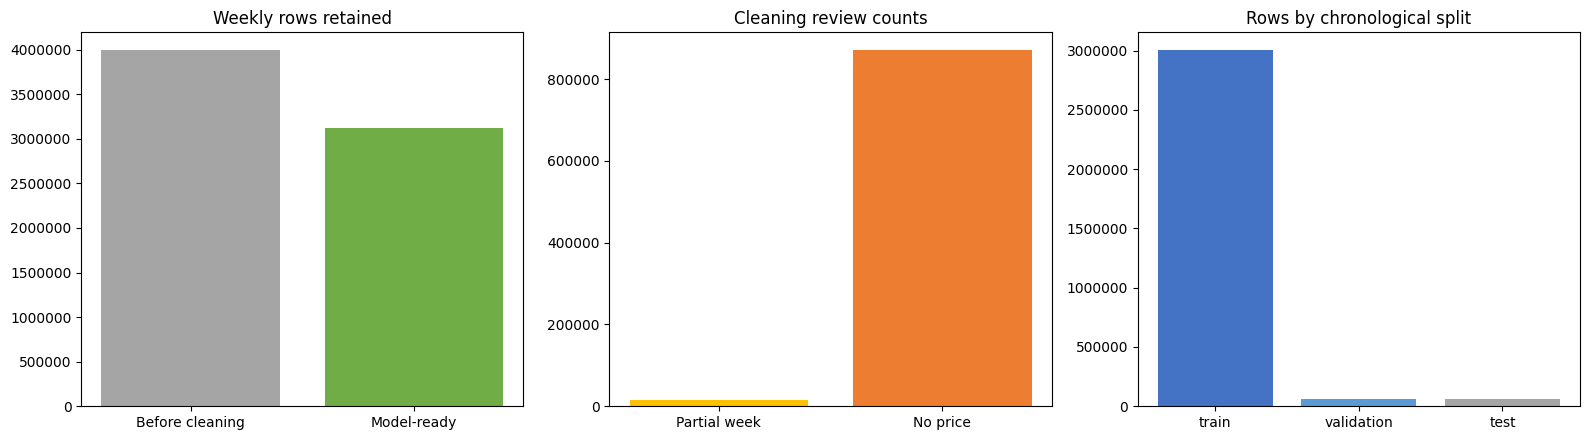

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(["Before cleaning", "Model-ready"], [summary["weekly_rows_before_cleaning"], summary["output_rows"]], color=["#A5A5A5", "#70AD47"])
axes[0].set_title("Weekly rows retained")
axes[0].ticklabel_format(style="plain", axis="y")

removal_values = [summary["partial_week_rows"], summary["missing_price_week_rows"]]
axes[1].bar(["Partial week", "No price"], removal_values, color=["#FFC000", "#ED7D31"])
axes[1].set_title("Cleaning review counts")
axes[1].ticklabel_format(style="plain", axis="y")

historical_splits = split_summary.loc[split_summary["split"].isin(["train", "validation", "test"])]
axes[2].bar(historical_splits["split"], historical_splits["rows"], color=["#4472C4", "#5B9BD5", "#A5A5A5"])
axes[2].set_title("Rows by chronological split")
axes[2].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

## 8. Verify saved data and write reports

The final checks read the Parquet dataset metadata independently, verify row counts and keys, and save small reports that can be committed to GitHub.

In [8]:
saved_dataset = pads.dataset(PROCESSED_DIR, format="parquet")
saved_row_count = saved_dataset.count_rows()
assert saved_row_count == summary["output_rows"]
assert summary["source_foods_series"] == 14_370
assert summary["source_daily_cells"] == 14_370 * 1_941
assert summary["duplicate_output_keys"] == 0
assert summary["required_output_nulls"] == 0
assert split_counts["outside_split"] == 0

cleaning_summary = pd.DataFrame([
    {"metric": key, "value": value}
    for key, value in summary.items()
])
cleaning_summary.to_csv(REPORT_DIR / "cleaning_summary.csv", index=False)
split_summary.to_csv(REPORT_DIR / "split_summary.csv", index=False)
split_plan.to_csv(REPORT_DIR / "split_plan.csv", index=False)

cleaning_findings = {
    "sales_outlier_threshold_daily_units": SALES_OUTLIER_THRESHOLD,
    "summary": summary,
    "split_counts": split_counts,
    "rules": {
        "zero_sales": "kept",
        "sales_outliers": "kept and flagged",
        "empty_events": "No event",
        "partial_weeks": "excluded",
        "weeks_without_price": "excluded as inactive assortment",
        "raw_files": "never overwritten",
    },
}
with (REPORT_DIR / "cleaning_findings.json").open("w", encoding="utf-8") as file:
    json.dump(cleaning_findings, file, indent=2, ensure_ascii=False, default=lambda value: value.item() if hasattr(value, "item") else str(value))

print("Saved rows verified:", f"{saved_row_count:,}")
print("Duplicate output keys:", summary["duplicate_output_keys"])
print("Required output nulls:", summary["required_output_nulls"])
print("Parquet parts:", summary["parquet_parts"])
print("Processed data folder:", PROCESSED_DIR)

Saved rows verified: 3,118,862
Duplicate output keys: 0
Required output nulls: 0
Parquet parts: 38
Processed data folder: F:\7) AI-ML_Fundamental_Project\Git_Desktop\retail-demand-forecasting\data\processed\m5_foods_weekly


## 9. Result

The complete `FOODS` category is now represented as clean weekly records with calendar, SNAP, event, price, outlier, and chronological-split information. The next project task is EDA and leakage-safe feature engineering. Model training must not start until these cleaning results and split dates are reviewed.